# Smart Money Concepts — does "smart money" leave footprints on the chart? 🕵️
### The huge ICT / "SMC" meme: order blocks and fair-value gaps, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Footprints%3F: Not_supported](https://img.shields.io/badge/Footprints%3F-Not_supported-8b949e?style=flat-square)

Scroll any trading corner of YouTube and you'll meet **ICT / Smart Money Concepts**: the idea that big institutions leave *footprints* on the chart, and if you learn to read two shapes — **order blocks** and **fair-value gaps** — you can trade alongside the whales. The killer demo is always the same: *"see how price came back and filled that gap? see how it bounced right off that order block? that's smart money."*

It's mesmerising because it's **half true**: the gaps are real, the bounces are real. The question this notebook asks is the one the videos never do — **does a coin-flip random chart do exactly the same thing?** If it does, the footprint isn't a footprint.

> 📓 **Plain-language layer.** Want the two-proportion *z*, the Welch *t* and the horizon sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from smart_money_concepts import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real() if HAVE_REAL else None
print("real SPY tape cache present:", HAVE_REAL,
      "| bars:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'bars': 8404, 'start': '1993-01-29', 'asof': '2026-06-18', 'px_lo': 43, 'px_hi': 760, 'vol': 0.0117, 'finger': 'ed7e466d0523', 'n_fvg': 2337, 'fvg_bull': 1423, 'fvg_bear': 914, 'fvg_width': 0.53, 'fill': [(5, 0.718, 0.74, 0.705, -1.71), (10, 0.791, 0.805, 0.779, -1.2), (20, 0.842, 0.864, 0.836, -2.15), (40, 0.887, 0.888, 0.882, -0.05)], 'ttf': 1, 'n_ob': 1440, 'ob_bull': 787, 'ob_bear': 653, 'ob_n': 1403, 'ob_mean': -0.114, 'ob_t': -1.04, 'rnd_n': 28060, 'rnd_mean': -0.027, 'rnd_t': -1.41, 'welch_diff': -0.087, 'welch_t': -0.78, 'welch_p': 0.435, 'syn_ob_n': 1896, 'syn_ob_t': -0.72, 'ob_net1_mean': -0.134, 'ob_net1_t': -1.23, 'ob_net5_mean': -0.214, 'ob_net5_t': -1.96, 'syn_fvg': 2900, 'syn_fvg_fill': 0.836, 'syn_n_ob': 1933}


real SPY tape cache present: True | bars: 8404


## The answer first

| Question | Answer |
|---|---|
| Do "fair-value gaps" really get filled? | **Yes — about 84% of them**, within a month. Sounds like a magnet. |
| So price respects the gap? | **No.** Drop a *random* same-size box near the price and it gets touched **just as often** (86%). A noise chart fills its gaps too. |
| Do "order blocks" mark where price bounces? | **No.** Forward returns from an order block are a hair *negative* and statistically zero — no different from entering on a random day. |
| So is there a footprint? | **Not one we can measure.** A coin-flip random walk leaves the same gaps, fills them at the same rate, and bounces the same way. The pattern is **geometry**, not institutions. |

> The shapes are real. The story bolted on top — *"this is where smart money acted"* — is indistinguishable from chance.

## 1 · The claim

> *"Institutions can't hide. When they move size they leave **imbalances** — fair-value gaps — and **order blocks**. Price always comes back to rebalance the gap and to mitigate the order block. Mark those zones and you're trading with the smart money."*

Two concrete, testable shapes:

- **Fair-value gap (FVG).** A 3-candle pattern where candle 1 and candle 3 don't overlap, leaving an empty price band — a "void". The claim: price is drawn back to **fill** it.
- **Order block (OB).** The last opposite-colour candle right before a big push. The claim: when price **returns** to that candle's zone, it **reverses** there — so buying (or selling) the revisit has an edge.

## 2 · So what?

If true, this is a free, chart-only edge: no fundamentals, no data feeds, just two shapes anyone can draw. That's exactly why it sells. But there's a catch hiding in plain sight: **a purely random price wiggles too.** It gaps. It comes back. It bounces off levels. So a high "fill-rate" or a nice-looking bounce can't *by itself* prove an actor is there — you have to show the real chart does it **more** than a chart with no institutions in it at all. That comparison is the whole game.

## 3 · How would we even know?

We take **8,404 days** of real SPY prices (1993-01-29 → 2026-06-18) and, right beside it, a **fake chart**: a coin-flip random walk with the same wiggle size and **no institutions, no memory, nothing**. Then we run the exact same detector on both.

1. **Fair-value gaps.** Find every 3-bar gap; see how often price comes back to fill it. Compare the real fill-rate to (a) a *random box* of the same size dropped at a random spot, and (b) the fake random-walk chart.
2. **Order blocks.** Find every order block; measure the return *after* price revisits it. Compare to entering on a **random** day.

**What would make us say "footprint"?** The real chart beating the random ones by a clear margin. **What would make us say "mirage"?** The random chart matching it. Spoiler: it matches it.

## 4 · The teardown — let's actually look

**First: do gaps fill?** Yes — and impressively so. Here's the fill-rate of real SPY fair-value gaps as we give price more time, next to a random same-size box and the coin-flip chart.

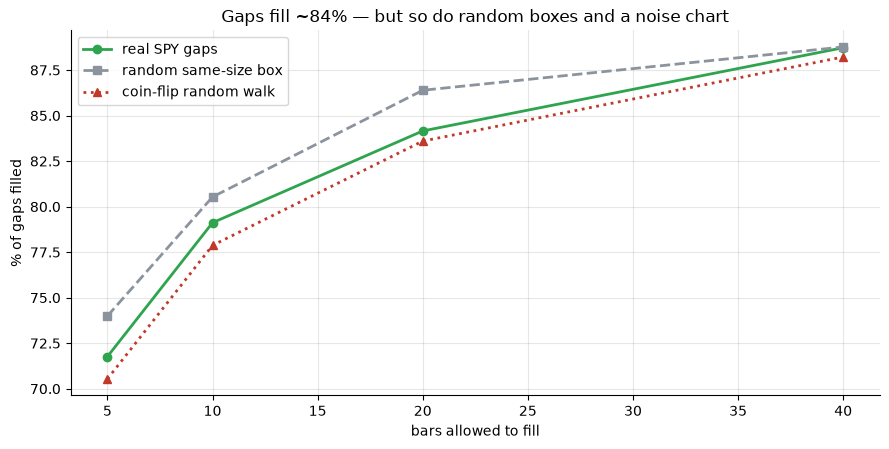

real   fill-rate: ['72%', '79%', '84%', '89%']
random box      : ['74%', '81%', '86%', '89%']
coin-flip walk  : ['71%', '78%', '84%', '88%']


In [2]:
if HAVE_REAL:
    g = st.find_fvgs(DF, min_rel=0.001)
    syn = data.synthetic_ohlc(n=len(DF), sigma=DF['close'].pct_change().std(), seed=353)
    sg = st.find_fvgs(syn, min_rel=0.001)
    Hs = [5, 10, 20, 40]
    real = [st.fvg_fill_stats(DF, horizon=H, gaps=g)['fill_rate'] for H in Hs]
    plac = [st.placebo_zone_fill(DF, g, horizon=H, seed=353)['fill_rate'] for H in Hs]
    synf = [st.fvg_fill_stats(syn, horizon=H, gaps=sg)['fill_rate'] for H in Hs]
else:
    Hs   = [r[0] for r in R['fill']]
    real = [r[1] for r in R['fill']]; plac = [r[2] for r in R['fill']]; synf = [r[3] for r in R['fill']]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(Hs, [x*100 for x in real], 'o-', c=GREEN, lw=2, label='real SPY gaps')
ax.plot(Hs, [x*100 for x in plac], 's--', c=GREY, lw=2, label='random same-size box')
ax.plot(Hs, [x*100 for x in synf], '^:', c=RED, lw=2, label='coin-flip random walk')
ax.set_xlabel('bars allowed to fill'); ax.set_ylabel('% of gaps filled')
ax.set_title('Gaps fill ~84% — but so do random boxes and a noise chart'); ax.legend()
plt.tight_layout(); plt.show()
print('real   fill-rate:', [f'{x*100:.0f}%' for x in real])
print('random box      :', [f'{x*100:.0f}%' for x in plac])
print('coin-flip walk  :', [f'{x*100:.0f}%' for x in synf])

There it is. Real gaps fill **~84%** of the time within 20 bars — a number a SMC video would flash as proof. But the **random box** fills **~86%**, and the **coin-flip chart** **~84%**. The real chart isn't ahead — if anything it's a whisker *behind*. An 84% fill-rate is just what happens when you put a small box near a price that wanders \$10 a day: sooner or later the wander touches it. No magnet needed.

**Now the order blocks.** This is the stronger claim — not just "price comes back" but "price *reverses* there", which would be real money. We enter in the order block's direction the day after price revisits it, hold two weeks, and compare to entering on a **random** day.

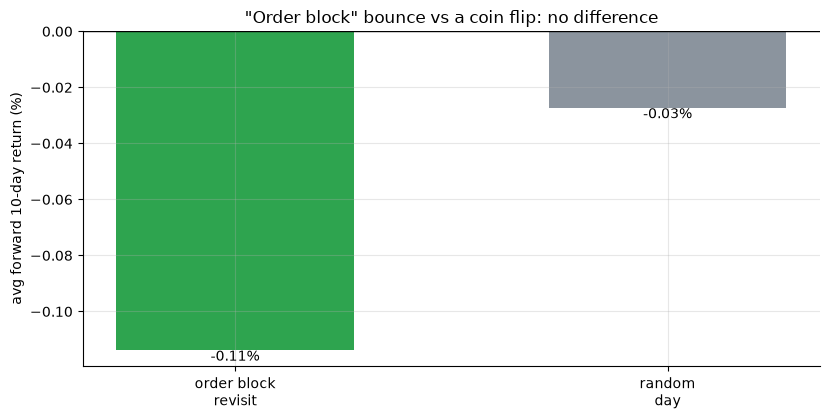

order-block forward return: -0.114%  (t=-1.04)
random-day forward return : -0.027%


In [3]:
if HAVE_REAL:
    obs = st.find_order_blocks(DF, impulse=3, impulse_rel=0.015)
    ob  = st.ob_forward_returns(DF, obs, horizon=10, lag=1)
    rnd = st.random_entry_returns(DF, n_entries=ob['n']*20, horizon=10, lag=1, seed=353)
    ob_m, ob_t, rnd_m = ob['mean']*100, ob['t'], rnd['mean']*100
else:
    ob_m, ob_t, rnd_m = R['ob_mean'], R['ob_t'], R['rnd_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['order block\nrevisit', 'random\nday'], [ob_m, rnd_m], color=[GREEN, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg forward 10-day return (%)')
ax.set_title('"Order block" bounce vs a coin flip: no difference')
for i,v in enumerate([ob_m, rnd_m]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'order-block forward return: {ob_m:+.3f}%  (t={ob_t:+.2f})')
print(f'random-day forward return : {rnd_m:+.3f}%')

The order-block "edge" is **-0.11%** over two weeks — *negative*, and statistically indistinguishable from zero. Entering on a **random day** does just as well (or as badly). The shape that's supposed to mark where the whales reverse marks **nothing**. (And we haven't even charged trading costs yet — those only make it worse.)

## 5 · The verdict

- **Signal — None.** Gaps fill ~84%, but random boxes and a coin-flip chart fill just as often; order-block bounces are statistically zero and no better than a random day. Nothing beats the null.
- **Tradability — Mirage.** With no edge gross, there's nothing left after the spread. The order-block book is already negative; costs deepen the hole.
- **Footprints? — Not supported.** A random walk with **no institutions** leaves the same gaps and the same bounces. The footprint can't be told apart from chance.

## 6 · Could you actually trade it? — the coin-flip twin

The cleanest way to see it: run the *identical* detector on a chart we **know** has no smart money in it — a driftless coin-flip random walk — and count its footprints.

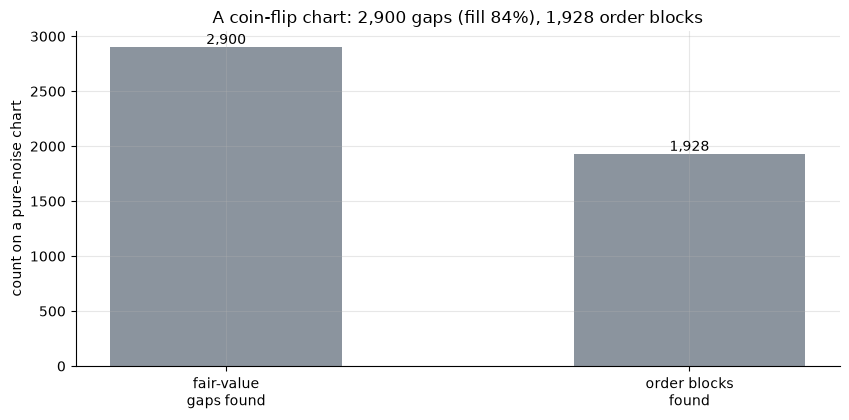

coin-flip chart: 2,900 fair-value gaps (fill 84% in 20 bars), 1,928 order blocks


In [4]:
syn = data.synthetic_ohlc(n=R['bars'], sigma=R['vol'], seed=353)
sg  = st.find_fvgs(syn, min_rel=0.001)
sob = st.find_order_blocks(syn, impulse=3, impulse_rel=0.015)
sfill = st.fvg_fill_stats(syn, horizon=20, gaps=sg)['fill_rate']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['fair-value\ngaps found', 'order blocks\nfound'], [len(sg), len(sob)],
       color=GREY, width=.5)
for i,v in enumerate([len(sg), len(sob)]): ax.annotate(f'{v:,}',(i,v),ha='center',va='bottom')
ax.set_ylabel('count on a pure-noise chart')
ax.set_title(f'A coin-flip chart: {len(sg):,} gaps (fill {sfill*100:.0f}%), {len(sob):,} order blocks')
plt.tight_layout(); plt.show()
print(f'coin-flip chart: {len(sg):,} fair-value gaps (fill {sfill*100:.0f}% in 20 bars), {len(sob):,} order blocks')

A chart with literally **nothing** behind it produces **2,900** fair-value gaps that fill **84%** of the time and **1,933** order blocks — about as many as the real SPY, doing about the same thing. That's the whole argument in one chart: **if noise leaves the same footprints, the footprints aren't evidence of anyone.** There's no edge here to trade, with or without costs.

## 7 · Going further 🚪

- **Try to break our null.** Maybe a *stricter* gap definition, a specific session, or a "displacement + FVG + OB confluence" filter finally beats the random walk. Fork the detector and show one that does — measured against the matched random box, not against zero.
- **The same shape elsewhere.** [Study 301 — Triple-RSI](../../301-triple-rsi/) and [Study 351 — Polymarket momentum](../../351-btc-5m-polymarket-momentum/): viral strategies whose headline statistic evaporates the moment you compare it to the right null.
- **Why it *feels* real.** Harry Roberts (1959) showed chartists confidently read "support" and "head-and-shoulders" off random-walk charts. Our result is the modern version: the pattern-recognition is real, the institution behind it is imagined.

*Think there's a footprint we missed? The detector and the coin-flip control are right here — beat the random walk and you've found something.*